### PART 1: Power Law for Global Coupling Maps (Figure 5)

Loading griffiths_data.csv...
Loading griffiths_data_extra_eps.csv...
Loading griffiths_data_extra_eps2.csv...

Available epsilon:
[0.125, 0.15, 0.175, 0.18, 0.19, 0.195, 0.2, 0.205, 0.21, 0.225, 0.23, 0.235, 0.24, 0.245, 0.25, 0.35, 0.4]


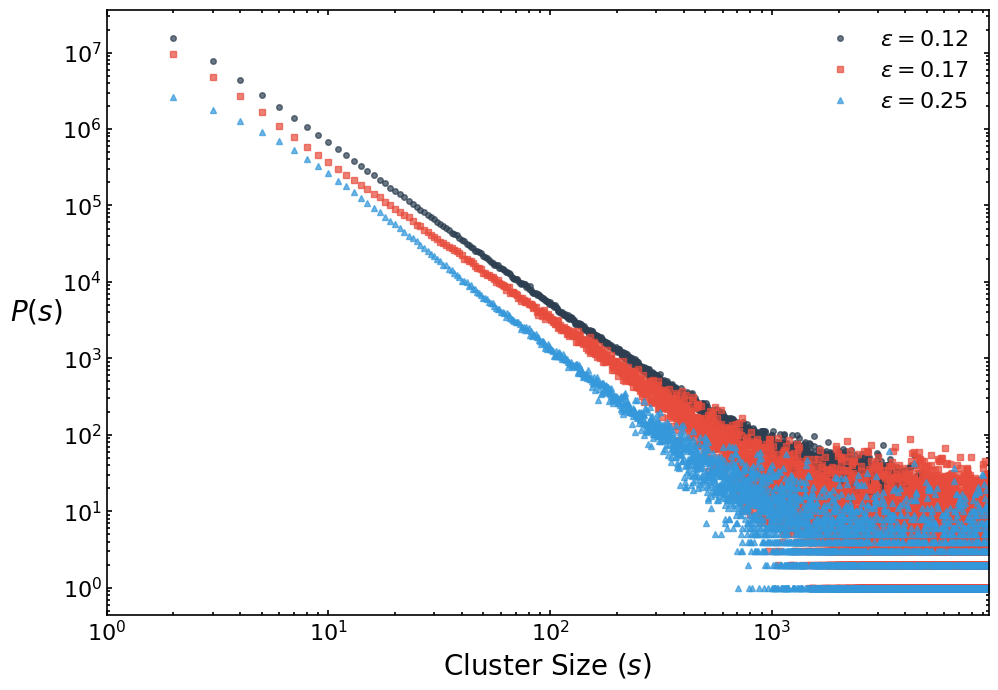

In [24]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Read epsilon from the column name
def extract_epsilon(column_name):
    # Works with columns like: eps_0.450, 0.450, 0.45
    text = str(column_name).strip()
    match = re.search(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", text)
    if match is None:
        raise ValueError(f"Could not extract epsilon from '{column_name}'.")
    return float(match.group())


# Load and merge data
CASE2_FILES = ["griffiths_data.csv", "griffiths_data_extra_eps.csv", "griffiths_data_extra_eps2.csv"]

dataframes = []
for fname in CASE2_FILES:
    print(f"Loading {fname}...")
    try:
        current_df = pd.read_csv(fname, index_col="cluster_size")
    except FileNotFoundError:
        raise FileNotFoundError(f"File '{fname}' not found.")

    # Ensure numeric, incremental index
    current_df.index = pd.to_numeric(current_df.index, errors="coerce")
    current_df = current_df.loc[current_df.index.notna()].copy()
    current_df.index = current_df.index.astype(int)

    # Convert column names to numeric epsilon values
    current_df.columns = [extract_epsilon(column) for column in current_df.columns]
    current_df = current_df.apply(pd.to_numeric, errors="coerce")
    dataframes.append(current_df)

# Merge both files by columns
df = pd.concat(dataframes, axis=1).fillna(0)
df = df.sort_index()
df = df.reindex(sorted(df.columns), axis=1)

# Check for duplicated epsilon
duplicated_eps = df.columns[df.columns.duplicated()].tolist()
if duplicated_eps:
    raise ValueError(f"Duplicated epsilon between files: {duplicated_eps}")

print("\nAvailable epsilon:")
print(list(df.columns))


# Config
FLOOR = 1
EPSILONS_TO_PLOT = [0.125, 0.175, 0.25]

# Check that they exist
missing_epsilons = [
    requested_eps
    for requested_eps in EPSILONS_TO_PLOT
    if not any(np.isclose(requested_eps, available_eps) for available_eps in df.columns)
]
if missing_epsilons:
    raise KeyError(
        f"These epsilon were not found: {missing_epsilons}\n"
        f"Available epsilon: {list(df.columns)}"
    )

# Colors and markers
colors = {0.125: "#2c3e50", 0.175: "#e74c3c", 0.25: "#3498db"}
markers = {0.125: "o", 0.175: "s", 0.25: "^"}


# Plot
plt.figure(figsize=(10, 7))
x_val = df.index.values.astype(float)

for requested_eps in EPSILONS_TO_PLOT:
    # Find the matching column with numeric tolerance
    eps_column = next(
        available_eps
        for available_eps in df.columns
        if np.isclose(available_eps, requested_eps)
    )
    eps = float(eps_column)
    y_val = df[eps_column].values.astype(float)

    # Floor for the plot
    mask_floor = (y_val >= FLOOR) & (x_val > 0) & np.isfinite(y_val)
    x_plot = x_val[mask_floor]
    y_plot = y_val[mask_floor]
    if len(x_plot) == 0:
        continue

    label_txt = fr"$\epsilon={eps:.2f}$"
    plt.loglog(
        x_plot,
        y_plot,
        linestyle="none",
        marker=markers[requested_eps],
        markersize=4,
        color=colors[requested_eps],
        alpha=0.7,
        label=label_txt)

# Cannot start at zero because the axis is logarithmic
plt.xlim(1, 10000 - 500)
plt.xlabel(r"Cluster Size ($s$)", fontsize=20)
plt.ylabel(r"$P(s)$", fontsize=20, rotation=0)

legend = plt.legend(fontsize=16,frameon=False,fancybox=False,edgecolor="black",loc="upper right")
legend.get_frame().set_linewidth(1.0)

plt.grid(False)
ax = plt.gca()
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_linewidth(1.2)

ax.tick_params(width=1.2,which="both",labelsize=16,direction="in",top=True,right=True)
ax.yaxis.set_label_coords(-0.08, 0.478)
plt.tight_layout()
filename = "Fig5_Power_Law.pdf"
plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### PART 2: Power Law for Small World Networks (Figure 7)

Loading SWN_Heterogeneity_data.csv...
Loading SWN_Heterogeneity_data_extra_eps.csv...

Available epsilon:
[0.45, 0.5, 0.6, 0.65, 0.75, 0.8, 0.85, 0.9, 0.95]


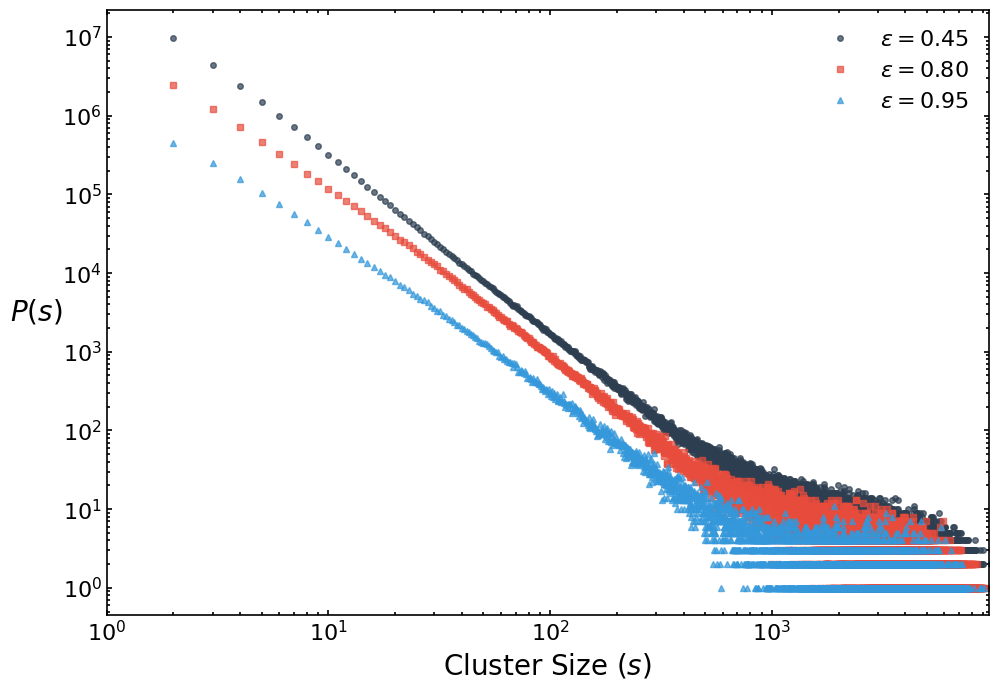

In [27]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Read epsilon from the column name
def extract_epsilon(column_name):
    # Works with columns like: eps_0.450, 0.450, 0.45
    text = str(column_name).strip()
    match = re.search(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", text)
    if match is None:
        raise ValueError(f"Could not extract epsilon from '{column_name}'.")
    return float(match.group())


# Load and merge data
CASE2_FILES = ["SWN_Heterogeneity_data.csv", "SWN_Heterogeneity_data_extra_eps.csv"]

dataframes = []
for fname in CASE2_FILES:
    print(f"Loading {fname}...")
    try:
        current_df = pd.read_csv(fname, index_col="cluster_size")
    except FileNotFoundError:
        raise FileNotFoundError(f"File '{fname}' not found.")

    # Ensure numeric, incremental index
    current_df.index = pd.to_numeric(current_df.index, errors="coerce")
    current_df = current_df.loc[current_df.index.notna()].copy()
    current_df.index = current_df.index.astype(int)

    # Convert column names to numeric epsilon values
    current_df.columns = [extract_epsilon(column) for column in current_df.columns]
    current_df = current_df.apply(pd.to_numeric, errors="coerce")
    dataframes.append(current_df)

# Merge both files by columns
df = pd.concat(dataframes, axis=1).fillna(0)
df = df.sort_index()
df = df.reindex(sorted(df.columns), axis=1)

# Check for duplicated epsilon
duplicated_eps = df.columns[df.columns.duplicated()].tolist()
if duplicated_eps:
    raise ValueError(f"Duplicated epsilon between files: {duplicated_eps}")

print("\nAvailable epsilon:")
print(list(df.columns))


# Config
FLOOR = 1
EPSILONS_TO_PLOT = [0.45, 0.80, 0.95]

# Check that they exist
missing_epsilons = [
    requested_eps
    for requested_eps in EPSILONS_TO_PLOT
    if not any(np.isclose(requested_eps, available_eps) for available_eps in df.columns)
]
if missing_epsilons:
    raise KeyError(
        f"These epsilon were not found: {missing_epsilons}\n"
        f"Available epsilon: {list(df.columns)}"
    )

# Colors and markers
colors = {0.45: "#2c3e50", 0.80: "#e74c3c", 0.95: "#3498db"}
markers = {0.45: "o", 0.80: "s", 0.95: "^"}


# Plot
plt.figure(figsize=(10, 7))
x_val = df.index.values.astype(float)

for requested_eps in EPSILONS_TO_PLOT:
    # Find the matching column with numeric tolerance
    eps_column = next(
        available_eps
        for available_eps in df.columns
        if np.isclose(available_eps, requested_eps)
    )
    eps = float(eps_column)
    y_val = df[eps_column].values.astype(float)

    # Floor for the plot
    mask_floor = (y_val >= FLOOR) & (x_val > 0) & np.isfinite(y_val)
    x_plot = x_val[mask_floor]
    y_plot = y_val[mask_floor]
    if len(x_plot) == 0:
        continue

    label_txt = fr"$\epsilon={eps:.2f}$"
    plt.loglog(
        x_plot,
        y_plot,
        linestyle="none",
        marker=markers[requested_eps],
        markersize=4,
        color=colors[requested_eps],    
        alpha=0.7,
        label=label_txt)

# Cannot start at zero because the axis is logarithmic
plt.xlim(1, 10000 - 500)
plt.xlabel(r"Cluster Size ($s$)", fontsize=20)
plt.ylabel(r"$P(s)$", fontsize=20, rotation=0)

legend = plt.legend(fontsize=16,frameon=False,fancybox=False,edgecolor="black",loc="upper right")
legend.get_frame().set_linewidth(1.0)

plt.grid(False)
ax = plt.gca()
for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_linewidth(1.2)

ax.tick_params(width=1.2,which="both",labelsize=16,direction="in",top=True,right=True)
ax.yaxis.set_label_coords(-0.08, 0.478)
plt.tight_layout()
filename = "Fig5_Power_Law.pdf"
plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
plt.show()

### PART 3: Maximum Likelihood Estimation (Figure 8)

Case 1 (Global Coupled) epsilon: [0.125, 0.15, 0.175, 0.18, 0.2, 0.225, 0.23, 0.25]
Case 2 (Small World) epsilon: [0.45, 0.5, 0.6, 0.65, 0.75, 0.8, 0.85, 0.9, 0.95]


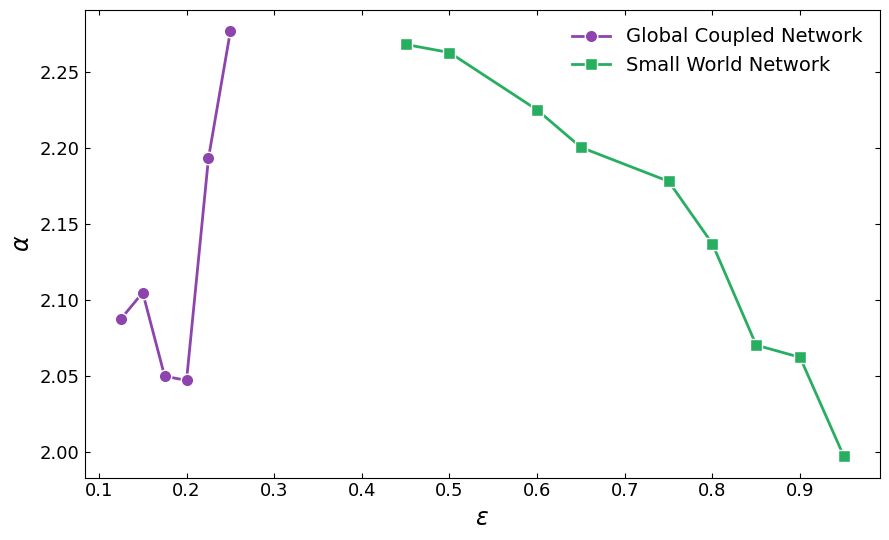

In [29]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp


CASE1_FILES = ["griffiths_data.csv", "griffiths_data2.csv"]
CASE2_FILES = ["SWN_Heterogeneity_data.csv", "SWN_Heterogeneity_data_extra_eps.csv"]

# Epsilon to plot for each case (set to None to use all)
CASE1_EPSILONS = [0.125, 0.15, 0.175, 0.2, 0.225, 0.25]
CASE2_EPSILONS = None

S_MIN = 10
S_MAX = 1000
ALPHA_BOUNDS = (0.01, 10.0)


def extract_epsilon(column_name):
    match = re.search(r"[-+]?(?:\d*\.\d+|\d+)(?:[eE][-+]?\d+)?", str(column_name))
    if match is None:
        raise ValueError(f"Invalid epsilon column: {column_name}")
    return float(match.group())


def load_cluster_data(files):
    dataframes = []
    for filename in files:
        data = pd.read_csv(filename, index_col="cluster_size")
        data.index = pd.to_numeric(data.index, errors="coerce")
        data = data.loc[data.index.notna()].copy()
        data.index = data.index.astype(int)
        data.columns = [extract_epsilon(column) for column in data.columns]
        data = data.apply(pd.to_numeric, errors="coerce").fillna(0.0)
        dataframes.append(data)

    data = pd.concat(dataframes, axis=1).fillna(0.0)
    if data.columns.duplicated().any():
        data = data.loc[:, ~data.columns.duplicated(keep="first")]

    return data.sort_index().reindex(sorted(data.columns), axis=1)


# Maximum likelihood estimate of the power-law exponent
def power_law_mle(cluster_sizes, counts):
    cluster_sizes = np.asarray(cluster_sizes, dtype=int)
    counts = np.asarray(counts, dtype=float)

    support = np.arange(S_MIN, S_MAX + 1, dtype=float)
    observed = np.zeros(support.size, dtype=float)

    mask = ((cluster_sizes >= S_MIN) & (cluster_sizes <= S_MAX)& np.isfinite(counts)& (counts >= 0))
    sizes_fit = cluster_sizes[mask]
    counts_fit = counts[mask]
    np.add.at(observed, sizes_fit - S_MIN, counts_fit)

    if observed.sum() == 0:
        return np.nan

    log_support = np.log(support)

    def negative_log_likelihood(alpha):
        log_weights = -alpha * log_support
        log_probability = log_weights - logsumexp(log_weights)
        return -np.sum(observed * log_probability)

    result = minimize_scalar(
        negative_log_likelihood, bounds=ALPHA_BOUNDS, method="bounded"
    )
    return float(result.x) if result.success else np.nan


def calculate_exponents(data, epsilons_to_plot=None):
    cluster_sizes = data.index.to_numpy(dtype=int)

    if epsilons_to_plot is not None:
        columns = [epsilon for epsilon in data.columns
            if any(np.isclose(epsilon, e) for e in epsilons_to_plot)]
    else:
        columns = list(data.columns)

    results = [
        {"epsilon": float(epsilon),
            "alpha": power_law_mle(
                cluster_sizes, data[epsilon].to_numpy(dtype=float))}
        for epsilon in columns]
    return pd.DataFrame(results).sort_values("epsilon")


case1_df = load_cluster_data(CASE1_FILES)
case2_df = load_cluster_data(CASE2_FILES)

# Available epsilon for each case (pick which ones to plot above)
print("Case 1 (Global Coupled) epsilon:", list(case1_df.columns))
print("Case 2 (Small World) epsilon:", list(case2_df.columns))

global_results = calculate_exponents(case1_df, CASE1_EPSILONS)
small_world_results = calculate_exponents(case2_df, CASE2_EPSILONS)


import matplotlib.ticker as ticker

plt.figure(figsize=(9, 5.5))
plt.plot(
    global_results["epsilon"],
    global_results["alpha"],
    marker="o",
    linewidth=2,
    color="#8e44ad",
    markeredgecolor="white",
    markersize=9,
    label="Global Coupled Network",
)
plt.plot(
    small_world_results["epsilon"],
    small_world_results["alpha"],
    marker="s",
    linewidth=2,
    color="#27ae60",
    markeredgecolor="white",
    markersize=9,
    label="Small World Network",
)

plt.xlabel(r"$\epsilon$", fontsize=17)
plt.ylabel(r"$\alpha$", fontsize=17)
plt.legend(frameon=False, fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.tick_params(which="both", direction="in", top=True, right=True, labelsize=13)
plt.tight_layout()
plt.savefig("Fig8_alpha_vs_epsilon_MLE.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()